In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
# https://research.unsw.edu.au/projects/unsw-nb15-dataset
"""
    download dataset in above link
"""

'\n    download dataset in above link\n'

In [4]:
dataPath = "dataset/UNSW_NB15_training-set.csv" 
test_path = "dataset/UNSW_NB15_testing-set.csv" 
df = pd.read_csv(dataPath)
test_df = pd.read_csv(test_path)
df.head(3)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0


In [5]:
df = df.drop(columns=['id','attack_cat'])
label = df["label"]
df = df.drop("label",axis = 1)

test_df = test_df.drop(columns=['id','attack_cat'])
test_label = test_df["label"]
test_df = test_df.drop("label",axis=1)

In [6]:
print(label.value_counts())
print(test_label.value_counts())

label
1    119341
0     56000
Name: count, dtype: int64
label
1    45332
0    37000
Name: count, dtype: int64


In [7]:
df = pd.get_dummies(df)
test_df = pd.get_dummies(test_df)

In [8]:
test_df = test_df.reindex(columns=df.columns, fill_value=0)

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_train = X_scaled[label == 0]

X_test_scaled = scaler.transform(test_df)

In [10]:
class CustomDataset(Dataset):
    def __init__(self,data):
        self.data = torch.tensor(data,dtype=torch.float32)
    
    def __len__(self):
        return self.data.shape[0]
    
    def __getitem__(self, index):
        return self.data[index]

In [11]:
class AutoEncoder(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,input_dim)
        )
    def forward(self,x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [12]:
train_dataset = CustomDataset(X_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [39]:
feature_dim = X_train.shape[1]
model = AutoEncoder(input_dim=feature_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 1e-3)

In [40]:
model

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=194, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=194, bias=True)
  )
)

In [ ]:
epochs = 30
patience = 3
min_delta = 1e-4

best_loss = float('inf')
patience_counter = 0
losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch.to(device)
        output = model(x)
        loss = criterion(output, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}: Training Loss = {avg_loss:.6f}")

    # Early stopping logic
    if best_loss - avg_loss > min_delta:
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


Epoch 1: Training Loss = 0.153372
Epoch 2: Training Loss = 0.103875
Epoch 3: Training Loss = 0.086366
Epoch 4: Training Loss = 0.085747
Epoch 5: Training Loss = 0.077827
Epoch 6: Training Loss = 0.077686
Epoch 7: Training Loss = 0.074772
Epoch 8: Training Loss = 0.074441
Epoch 9: Training Loss = 0.067590
Epoch 10: Training Loss = 0.061424
Epoch 11: Training Loss = 0.066150
Epoch 12: Training Loss = 0.066196
Epoch 13: Training Loss = 0.060325
Epoch 14: Training Loss = 0.056267
Epoch 15: Training Loss = 0.062946
Epoch 16: Training Loss = 0.056854
Epoch 17: Training Loss = 0.037306
Epoch 18: Training Loss = 0.084456
Epoch 19: Training Loss = 0.052540
Epoch 20: Training Loss = 0.053109
Early stopping triggered at epoch 20


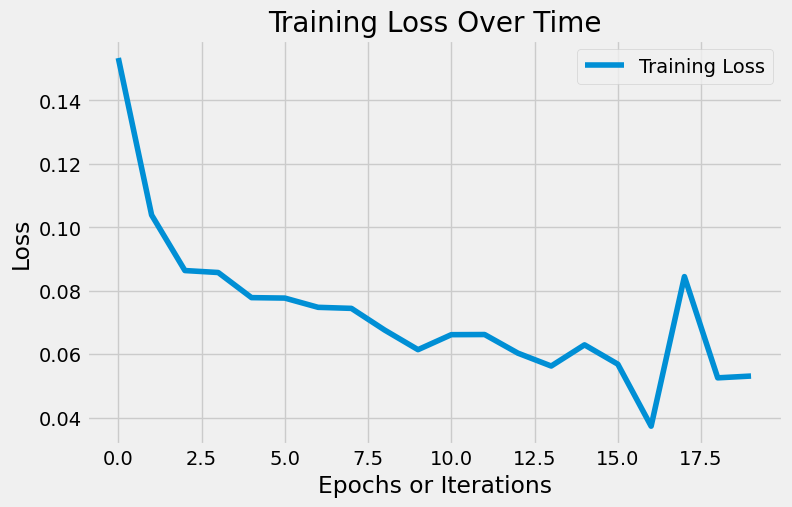

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Training Loss') 
plt.xlabel('Epochs or Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()


In [53]:
model.eval()
threshold = 0.008  # Set based on benign validation data
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    output = model (X_test_tensor)
    test_loss = torch.mean((X_test_tensor-output)**2,dim = 1)

y_pred = (test_loss>threshold).cpu().numpy()

y_true = test_label.values

In [54]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malicious"]))



Confusion Matrix:
[[34190  2810]
 [ 9806 35526]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.78      0.92      0.84     37000
   Malicious       0.93      0.78      0.85     45332

    accuracy                           0.85     82332
   macro avg       0.85      0.85      0.85     82332
weighted avg       0.86      0.85      0.85     82332



In [55]:
# Save model
torch.save(model.state_dict(), "saved_model/autoencoder_model_ver_1.0.pth")

## Combine Autoencoder and XGBoost

In [48]:
# Combine train + test data to create features for supervised model
X_full = scaler.transform(df) 
X_full_tensor = torch.tensor(X_full, dtype=torch.float32).to(device)

with torch.no_grad():
    recon_full = model(X_full_tensor)
    loss_full = torch.mean((X_full_tensor - recon_full) ** 2, dim=1)

reconstruction_error_full= loss_full.cpu().numpy().reshape(-1, 1)
reconstruction_error_test = test_loss.cpu().numpy().reshape(-1, 1)

X_with_error = np.hstack([X_full, reconstruction_error_full])
X_test_with_error = np.hstack([X_test_scaled, reconstruction_error_test])

In [49]:
feature_names = df.columns.tolist() 
X_with_error = np.hstack([X_scaled, reconstruction_error_full.reshape(-1, 1)])
X_with_error_df = pd.DataFrame(X_with_error, columns=feature_names + ['reconstruction_error'])

X_test_with_error = np.hstack([X_test_scaled, reconstruction_error_test.reshape(-1, 1)])
X_test_with_error_df = pd.DataFrame(X_test_with_error, columns=feature_names + ['reconstruction_error'])


In [50]:
from xgboost import XGBClassifier

clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
clf.fit(X_with_error_df, label)

y_pred = clf.predict(X_test_with_error)

print("Confusion Matrix:")
print(confusion_matrix(test_label, y_pred))

print("\nClassification Report:")
print(classification_report(test_label, y_pred))


d:\RAG_with_langchain\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:22:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
[[27498  9502]
 [  738 44594]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     37000
           1       0.82      0.98      0.90     45332

    accuracy                           0.88     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.88      0.87     82332



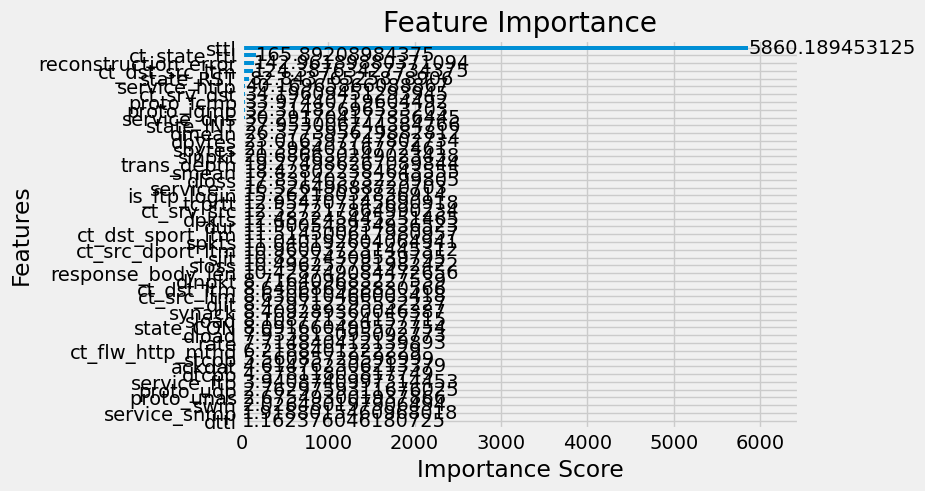

In [56]:
from xgboost import plot_importance

plot_importance(clf, height=0.5, importance_type='gain', xlabel='Importance Score')
plt.title("Feature Importance")
plt.show()



In [57]:
import joblib
joblib.dump(clf, "saved_model/xgb_model_ver_1.0.pkl")
joblib.dump(scaler, "saved_model/scaler_ver_1.0.pkl")

import json
with open("threshold_ver_1.0.json", "w") as f:
    json.dump({"threshold": 0.008}, f)


In [ ]:
"""
pseudo-code for inference:


def inference_pipeline(new_raw_data):
    # 1. Preprocess input features
    X_scaled = scaler.transform(new_raw_data)

    # 2. Autoencoder reconstruction
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    with torch.no_grad():
        reconstructed = autoencoder(X_tensor).cpu().numpy()

    # 3. Compute reconstruction errors (per feature)
    recon_error = (X_scaled - reconstructed) ** 2  # shape = (n_samples, n_features)

    # 4. Concatenate original + reconstruction error
    xgb_input = np.concatenate([X_scaled, recon_error], axis=1)

    # 5. Predict with XGBoost
    preds = xgboost_model.predict(xgb_input)

    return preds"""
